# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [3]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [4]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,  
    'open_confidence': 0,  
    'close_confidence': 0.2,  
    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 900,

    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [14]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 方法1: 使用天数分割（原来的方法）
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)

# 方法2: 使用日期范围分割（新的灵活方法）
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20260101",  # 训练集开始日期
    train_end="20260302",    # 训练集结束日期
    valid_start="20260303",  # 验证集开始日期
    valid_end="20260304",    # 验证集结束日期
    test_start="20251201",   # 测试集开始日期
    test_end="20251231"      # 测试集结束日期
)

总交易日数量: 77
交易日范围: 20251201 ~ 20260327
训练集: 20260105 ~ 20260302 (35天)
验证集: 20260303 ~ 20260304 (2天)
测试集: 20251201 ~ 20251231 (23天)


## 生成训练数据

In [24]:
print("生成训练集样本...")
X_train, y_train , feature_names= samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")

生成训练集样本...
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本
20260127: 产生 791 个样本
20260128: 产生 802 个样本
20260129: 产生 812 个样本
20260130: 产生 884 个样本
20260202: 加载失败 - cannot unpack non-iterable float object
20260203: 产生 833 个样本
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
20260302: 产生 821 个样本
训练集样本: X=(26875, 14), y=(26875,)


In [17]:
print("生成验证集样本...")
X_valid, y_valid , __= samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")

生成验证集样本...
20260303: 产生 794 个样本
20260304: 产生 886 个样本
验证集样本: X=(1680, 14), y=(1680,)


In [18]:
print("生成测试集样本...")
X_test, y_test ,__= samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...
20251201: 产生 805 个样本
20251202: 产生 794 个样本
20251203: 产生 791 个样本
20251204: 产生 778 个样本
20251205: 产生 813 个样本
20251208: 产生 803 个样本
20251209: 产生 858 个样本
20251210: 产生 754 个样本
20251211: 产生 807 个样本
20251212: 产生 766 个样本
20251215: 产生 809 个样本
20251216: 产生 865 个样本
20251217: 产生 808 个样本
20251218: 产生 787 个样本
20251219: 产生 769 个样本
20251222: 产生 821 个样本
20251223: 产生 857 个样本
20251224: 产生 803 个样本
20251225: 产生 821 个样本
20251226: 产生 822 个样本
20251229: 产生 821 个样本
20251230: 产生 799 个样本
20251231: 产生 794 个样本
测试集样本: X=(18545, 14), y=(18545,)


## 训练模型

In [19]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

训练 xgboost 模型...
[0]	validation_0-logloss:0.63124
[100]	validation_0-logloss:0.59675
[200]	validation_0-logloss:0.58288
[300]	validation_0-logloss:0.57628
[400]	validation_0-logloss:0.57233
[500]	validation_0-logloss:0.57013
[600]	validation_0-logloss:0.56834
[700]	validation_0-logloss:0.56770
[800]	validation_0-logloss:0.56706
[900]	validation_0-logloss:0.56640
[1000]	validation_0-logloss:0.56585
[1100]	validation_0-logloss:0.56551
[1200]	validation_0-logloss:0.56536
[1300]	validation_0-logloss:0.56518
[1400]	validation_0-logloss:0.56540
[1500]	validation_0-logloss:0.56587
[1600]	validation_0-logloss:0.56568
[1700]	validation_0-logloss:0.56594
[1800]	validation_0-logloss:0.56591
[1900]	validation_0-logloss:0.56614
[1999]	validation_0-logloss:0.56638
阈值优化完成: Best Threshold=0.3977, F0.5=0.4984

特征重要性（前10个）:
volatility        0.181636
hurst             0.124706
alpha_07          0.109938
num_trades        0.075585
hurst_exponent    0.072758
alpha_04          0.071742
volume            0.

In [ ]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_debug.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_debug.pkl


## 测试模型

测试集准确率: 0.6426

分类报告:
              precision    recall  f1-score   support

           0       0.80      0.66      0.72     13013
           1       0.43      0.60      0.50      5532

    accuracy                           0.64     18545
   macro avg       0.61      0.63      0.61     18545
weighted avg       0.69      0.64      0.66     18545

测试集准确率: 0.6426

分类报告:
              precision    recall  f1-score   support

           0       0.80      0.66      0.72     13013
           1       0.43      0.60      0.50      5532

    accuracy                           0.64     18545
   macro avg       0.61      0.63      0.61     18545
weighted avg       0.69      0.64      0.66     18545


PR曲线AUC: 0.4419
平均精度 (AP): 0.4421

预测概率统计:
  均值: 0.3527
  标准差: 0.1806
  最小值: 0.0059
  25%分位数: 0.2156
  中位数: 0.3510
  75%分位数: 0.4946
  最大值: 0.9118

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.3187, 标准差=0.1779
  标签1 (正类): 均值=0.4325, 标准差=0.1607


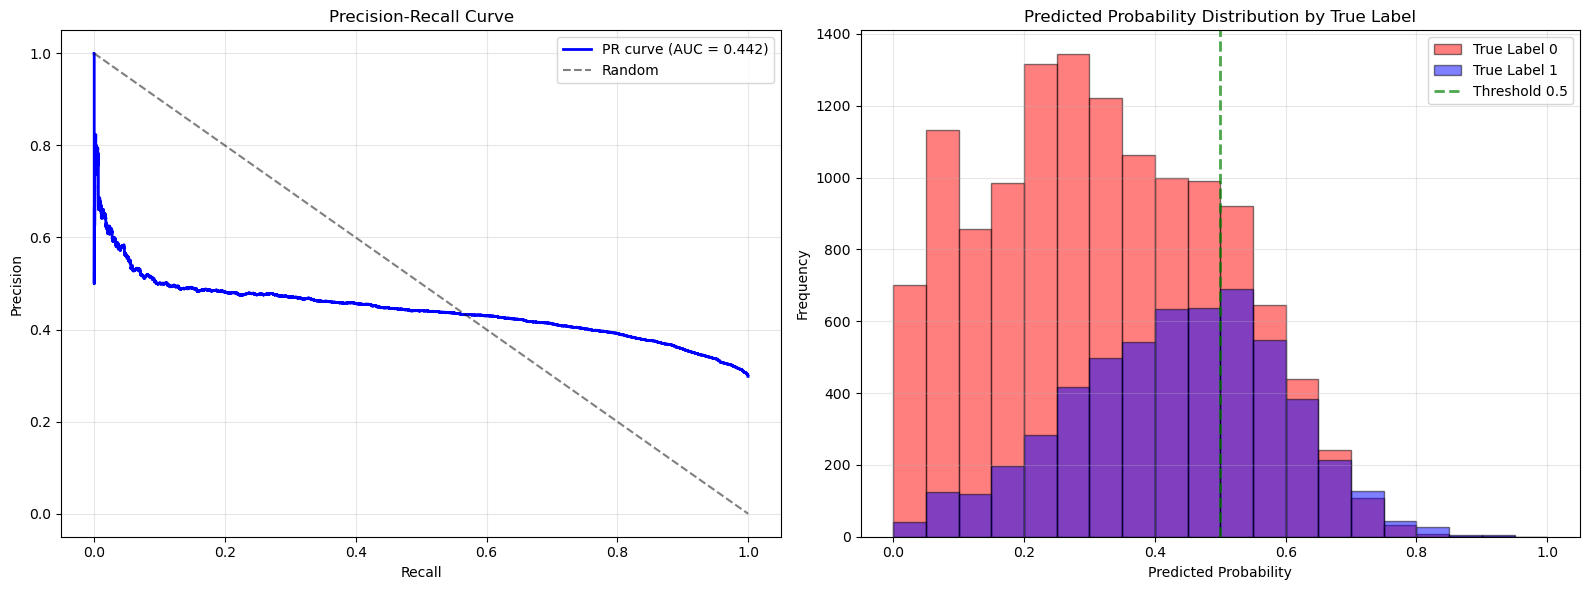

In [20]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

## 创建策略实例

In [11]:
model_path = f"/home/jovyan/work/model/delta_v2.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

日期 20260303 完成，盈亏: 6.80, 成交: 8次
日期 20260304 完成，盈亏: -4.70, 成交: 10次
日期 20260305 完成，盈亏: 8.30, 成交: 7次
日期 20260306 完成，盈亏: -2.20, 成交: 9次

instrument_id 511090
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
20260305
20260306
20260309
20260310
20260311
20260312
20260313
20260316
20260317
20260318
20260319
20260320
20260323
20260324
20260325
20260326
20260327

instrument_id 511100
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
202603

/home/jovyan/work/tactics_demo/delta/features.py:24: RuntimeWarning: invalid value encountered in scalar divide
  self.bid_book = self.last['bid_book']


日期 20260323 完成，盈亏: 39.10, 成交: 3次
日期 20260324 完成，盈亏: 1.80, 成交: 5次
日期 20260325 完成，盈亏: 1.30, 成交: 8次
日期 20260326 完成，盈亏: 9.20, 成交: 6次
日期 20260327 完成，盈亏: -6.60, 成交: 10次

instrument_id 511090
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
20260305
20260306
20260309
20260310
20260311
20260312
20260313
20260316
20260317
20260318
20260319
20260320
20260323
20260324
20260325
20260326
20260327

instrument_id 511100
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
2

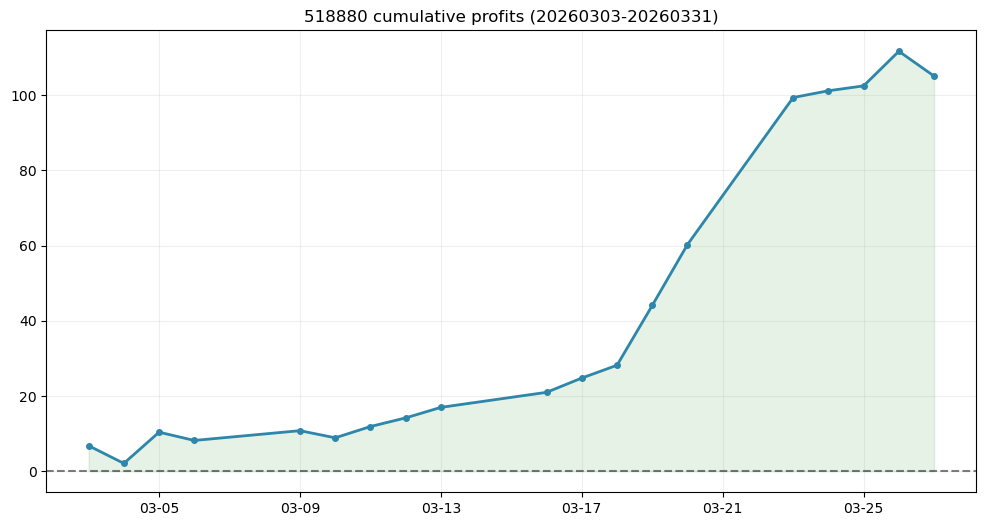

{'测试天数': 19, '累计总盈亏': np.float64(105.1), '总成交次数': 154, '日均盈亏': np.float64(5.53), '胜率(天)%': 78.95, '盈亏比(日均)': np.float64(2.09), '最大单日盈利': 39.1, '最大单日亏损': -6.6, '每笔交易平均盈利': np.float64(0.68)}


In [23]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from multi_day_backtest import backtest_multi_days, backtest_summary
from delta.strategy import StrategyDemo

result_df = backtest_multi_days(
    instrument_id=instrument_id,
    start_ymd='20260303',
    end_ymd='20260331',
    StrategyClass= StrategyDemo,
    model = model_path,
    param_dict=param_dict,
    official = False
)

summary = backtest_summary(result_df)
print(summary)

In [134]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(result_df)

,trade_ymd,profits,trades,trade_date
0,20260302,9.8,8,2026-03-02
1,20260303,3.9,7,2026-03-03
2,20260304,1.5,8,2026-03-04
3,20260305,0.9,9,2026-03-05
4,20260306,0.2,10,2026-03-06
5,20260309,-2.5,12,2026-03-09
6,20260310,-1.9,8,2026-03-10
7,20260311,4.0,7,2026-03-11
8,20260312,4.2,7,2026-03-12
9,20260313,1.9,9,2026-03-13


In [ ]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')

from parallel_backtest import backtest_multi_days_parallel
result_df = backtest_multi_days_parallel(
    instrument_id,
    start_ymd='20260303',
    end_ymd='20260331',
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    official=False,
    max_workers=4  # 使用4个CPU核心
)

开始并行回测，共 31 个交易日
使用 4 个进程


## 保存回测结果

In [135]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260415_060350
回测结果已保存到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260415_060350
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [ ]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("518880", "20260414", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_025053
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_042231
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_011936
已删除: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_061311

总共删除了 4 个文件夹


## 单日回测观察

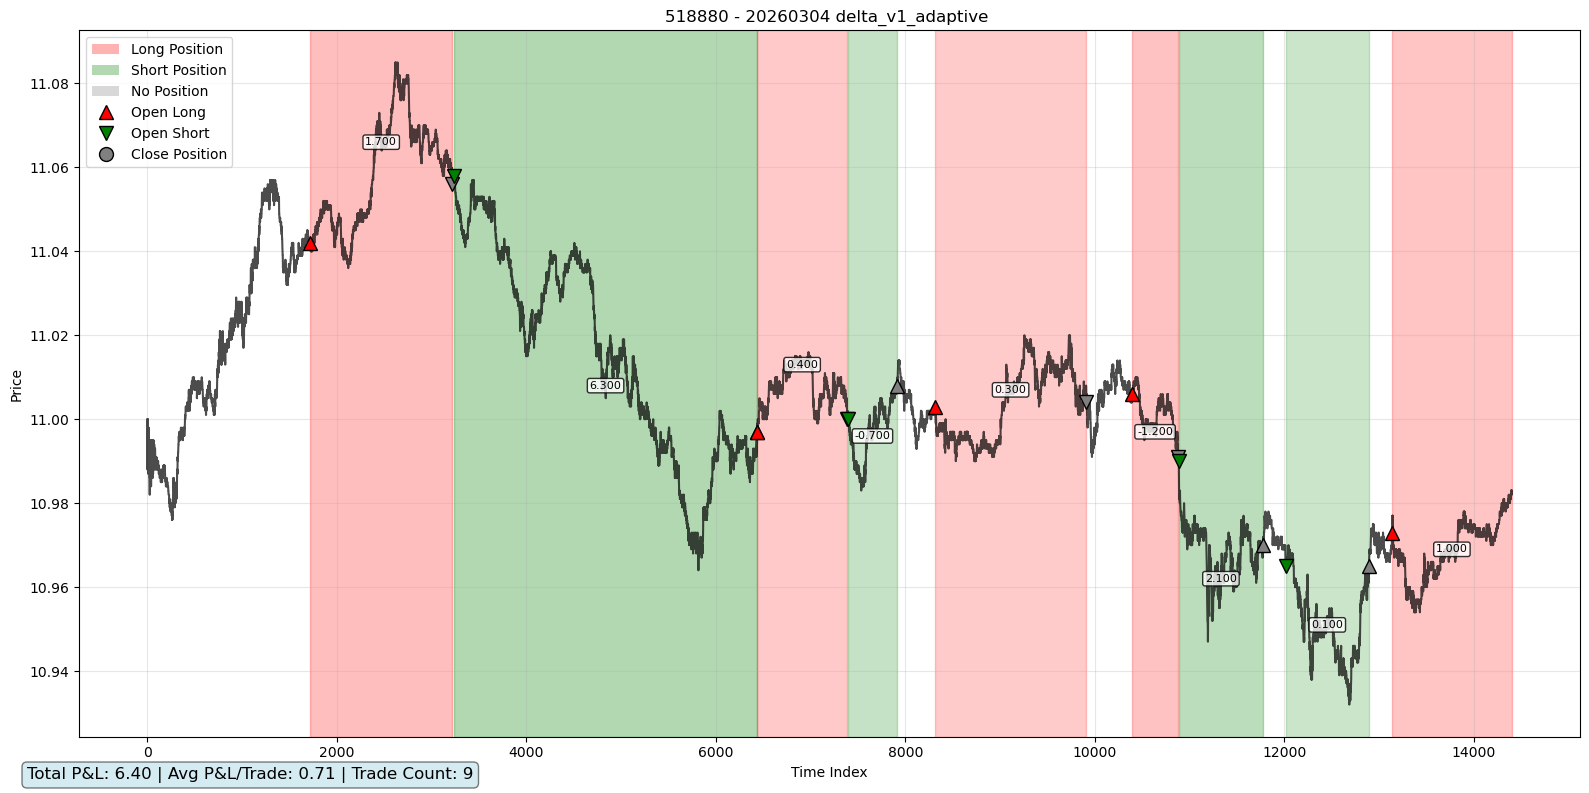

In [113]:
from single_day_backtest import single_day_backtest,plot_delta_history
strategy = StrategyDemo(model_path, param_dict)
hh = single_day_backtest(instrument_id,'20260304',StrategyDemo,model_path,param_dict,official = False)

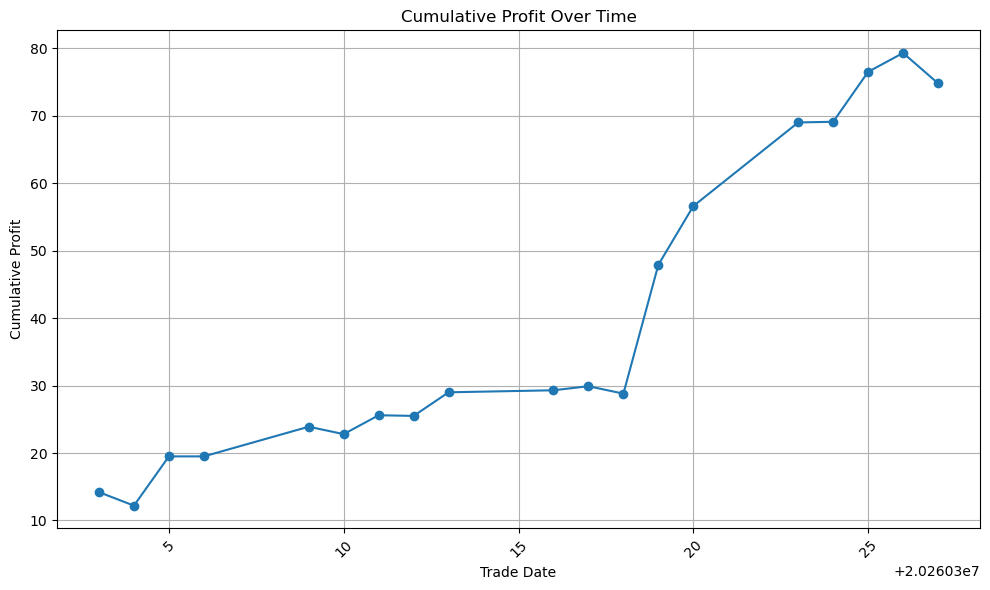

In [ ]:
summary = pd.read_csv('/home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_adaptive_20260414_084832/daily_results.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
